# Part 2.2: Cybersecurity — Synthetic Network Traffic with CICIDS 2017

## Loading and Exploring the Wednesday Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Wednesday-workingHours.pcap_ISCX.csv")
df.columns = df.columns.str.strip()  # column names have leading spaces

print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())

Shape: (692703, 79)

Label distribution:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


### Simplifying to a Binary Label: BENIGN vs. DoS

The five DoS sub-types are combined into a single "DoS" class, since some
sub-types (e.g. Heartbleed, 11 samples) are too rare for a GAN to learn.

Label_binary
BENIGN    440031
DoS       252672
Name: count, dtype: int64

Class balance:
Label_binary
BENIGN    0.635238
DoS       0.364762
Name: proportion, dtype: float64


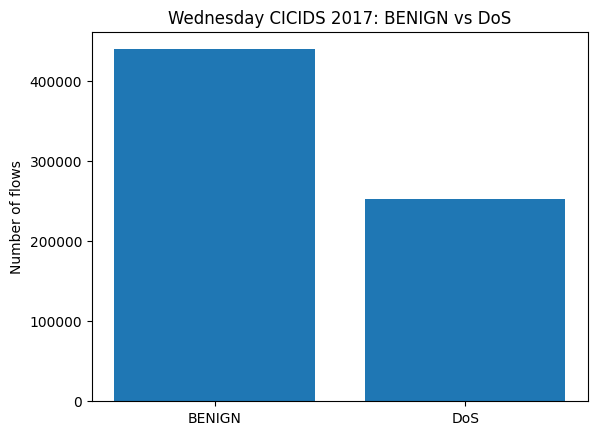

In [2]:
df["Label_binary"] = df["Label"].apply(lambda x: "BENIGN" if x == "BENIGN" else "DoS")

print(df["Label_binary"].value_counts())
print("\nClass balance:")
print(df["Label_binary"].value_counts(normalize=True))

plt.bar(df["Label_binary"].value_counts().index, df["Label_binary"].value_counts().values)
plt.ylabel("Number of flows")
plt.title("Wednesday CICIDS 2017: BENIGN vs DoS")
plt.show()

### Data Cleaning: Handling NaN and Infinite Values

`Flow Bytes/s` and `Flow Packets/s` are derived by dividing by flow duration,
producing NaN (0/0) or Inf (x/0) when duration is zero. Affected rows are dropped.

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns

print("Rows before cleaning:", len(df))
print("NaN count:", df[num_cols].isna().sum().sum())
print("Inf count:", np.isinf(df[num_cols]).sum().sum())

df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=num_cols).reset_index(drop=True)

print("Rows after cleaning:", len(df_clean))
print(f"Dropped {len(df) - len(df_clean)} rows ({(len(df)-len(df_clean))/len(df):.3%})")

print("\nClass balance after cleaning:")
print(df_clean["Label_binary"].value_counts())

Rows before cleaning: 692703
NaN count: 1008
Inf count: 1586
Rows after cleaning: 691406
Dropped 1297 rows (0.187%)

Class balance after cleaning:
Label_binary
BENIGN    439683
DoS       251723
Name: count, dtype: int64


### Feature Overview

In [4]:
feature_cols = [c for c in num_cols if c not in ["Label"]]
print(f"Number of numeric features: {len(feature_cols)}")

summary = df_clean[feature_cols].describe().T[["mean", "std", "min", "max"]]
print(summary.head(15))

Number of numeric features: 78
                                     mean           std         min  \
Destination Port             5.683120e+03  1.572234e+04         0.0   
Flow Duration                2.805421e+07  4.278968e+07        -1.0   
Total Fwd Packets            9.570718e+00  7.478982e+02         1.0   
Total Backward Packets       1.023296e+01  9.851272e+02         0.0   
Total Length of Fwd Packets  5.561296e+02  6.169395e+03         0.0   
Total Length of Bwd Packets  1.702833e+04  2.243276e+06         0.0   
Fwd Packet Length Max        2.340283e+02  6.042345e+02         0.0   
Fwd Packet Length Min        1.504801e+01  5.111307e+01         0.0   
Fwd Packet Length Mean       6.066592e+01  1.577708e+02         0.0   
Fwd Packet Length Std        8.305029e+01  2.263099e+02         0.0   
Bwd Packet Length Max        1.664662e+03  2.615384e+03         0.0   
Bwd Packet Length Min        3.389495e+01  6.463110e+01         0.0   
Bwd Packet Length Mean       5.529748e+02  7.9

### Additional Cleaning: Negative Flow Duration

A small number of rows (16, or 0.002%) have `Flow Duration = -1`, an invalid
value that also produces implausible negative `Flow Bytes/s` figures. These
are dropped as a likely logging artifact rather than genuine traffic.

In [5]:
invalid_duration = (df_clean["Flow Duration"] < 0).sum()
print(f"Rows with negative Flow Duration: {invalid_duration}")

df_clean = df_clean[df_clean["Flow Duration"] >= 0].reset_index(drop=True)
print(f"Rows after removing negative durations: {len(df_clean)}")
print("\nFinal class balance:")
print(df_clean["Label_binary"].value_counts())

Rows with negative Flow Duration: 21
Rows after removing negative durations: 691385

Final class balance:
Label_binary
BENIGN    439662
DoS       251723
Name: count, dtype: int64


## Normalising the Features

GAN training requires features on a comparable scale — otherwise the discriminator
can trivially separate real/fake based on scale alone, and gradients become unstable.
Each feature is scaled to [-1, 1] using MinMaxScaler, matching the Tanh output the
generator will use (same convention as the image-based GANs in Part 1 and Part 2.1).

In [6]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [c for c in df_clean.columns if c not in ["Label", "Label_binary"]]
print(f"Number of features: {len(feature_cols)}")

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(df_clean[feature_cols].values)

print("Scaled data shape:", X_scaled.shape)
print("Min/max after scaling:", X_scaled.min(), X_scaled.max())

Number of features: 78
Scaled data shape: (691385, 78)
Min/max after scaling: -1.0 1.0000000000000004


## Building the Tabular GAN

Since this data is tabular feature vectors (not images), the architecture uses
fully-connected layers, similar to Part 1's sine-wave GAN, but scaled up to handle
78 input features instead of 2.

In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

feature_dim = X_scaled.shape[1]
latent_dim = 32

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
batch_size = 256
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


class TabularGenerator(nn.Module):
    def __init__(self, latent_dim, feature_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, feature_dim),
            nn.Tanh(),  # matches [-1, 1] scaled features
        )

    def forward(self, z):
        return self.model(z)


class TabularDiscriminator(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


generator = TabularGenerator(latent_dim, feature_dim)
discriminator = TabularDiscriminator(feature_dim)

# Sanity check
test_noise = torch.randn(4, latent_dim)
test_fake = generator(test_noise)
test_output = discriminator(test_fake)
print("Generator output shape:", test_fake.shape)
print("Discriminator output shape:", test_output.shape)

Generator output shape: torch.Size([4, 78])
Discriminator output shape: torch.Size([4, 1])


## Training the Tabular GAN

In [8]:
lr = 0.0002
num_epochs = 50
beta1 = 0.5

loss_function = nn.BCELoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator.to(device)
discriminator.to(device)
print("Using device:", device)

Using device: cuda


In [9]:
d_losses = []
g_losses = []

for epoch in range(num_epochs):
    for i, (real_batch,) in enumerate(data_loader):
        real_batch = real_batch.to(device)
        current_batch_size = real_batch.size(0)

        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        # --- Train Discriminator ---
        optimizer_d.zero_grad()
        output_real = discriminator(real_batch)
        loss_d_real = loss_function(output_real, real_labels)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_batch = generator(noise)
        output_fake = discriminator(fake_batch.detach())
        loss_d_fake = loss_function(output_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        # --- Train Generator ---
        optimizer_g.zero_grad()
        output_fake_for_g = discriminator(fake_batch)
        loss_g = loss_function(output_fake_for_g, real_labels)
        loss_g.backward()
        optimizer_g.step()

        if i % 500 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i}/{len(data_loader)}] "
                  f"Loss D: {loss_d.item():.4f} Loss G: {loss_g.item():.4f}")

    d_losses.append(loss_d.item())
    g_losses.append(loss_g.item())

Epoch [1/50] Batch [0/2701] Loss D: 1.3643 Loss G: 0.6957
Epoch [1/50] Batch [500/2701] Loss D: 0.9692 Loss G: 1.0970
Epoch [1/50] Batch [1000/2701] Loss D: 0.5015 Loss G: 1.9246
Epoch [1/50] Batch [1500/2701] Loss D: 0.6604 Loss G: 1.5929
Epoch [1/50] Batch [2000/2701] Loss D: 0.7751 Loss G: 1.5332
Epoch [1/50] Batch [2500/2701] Loss D: 0.6882 Loss G: 1.4689
Epoch [2/50] Batch [0/2701] Loss D: 0.6952 Loss G: 1.4421
Epoch [2/50] Batch [500/2701] Loss D: 0.7190 Loss G: 1.4458
Epoch [2/50] Batch [1000/2701] Loss D: 0.6581 Loss G: 1.4969
Epoch [2/50] Batch [1500/2701] Loss D: 0.7817 Loss G: 1.4422
Epoch [2/50] Batch [2000/2701] Loss D: 0.6392 Loss G: 1.5213
Epoch [2/50] Batch [2500/2701] Loss D: 0.6460 Loss G: 1.5244
Epoch [3/50] Batch [0/2701] Loss D: 0.6548 Loss G: 1.5389
Epoch [3/50] Batch [500/2701] Loss D: 0.6438 Loss G: 1.5283
Epoch [3/50] Batch [1000/2701] Loss D: 0.6675 Loss G: 1.5422
Epoch [3/50] Batch [1500/2701] Loss D: 0.6330 Loss G: 1.5249
Epoch [3/50] Batch [2000/2701] Loss 

## Plotting the Training Losses

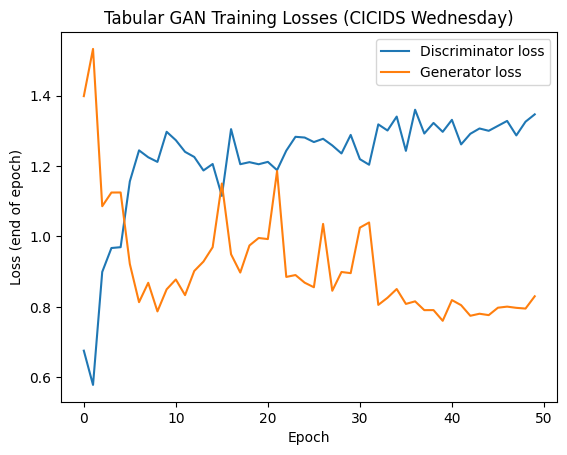

In [10]:
plt.plot(d_losses, label="Discriminator loss")
plt.plot(g_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (end of epoch)")
plt.legend()
plt.title("Tabular GAN Training Losses (CICIDS Wednesday)")
plt.show()

## Comparing Real vs. Generated Data: PCA and t-SNE

Since these are 78-dimensional feature vectors, we can't visualise them directly.
PCA and t-SNE both project high-dimensional data down to 2D for visual comparison.
PCA preserves global variance structure (linear), while t-SNE preserves local
neighbourhood structure (non-linear) — using both gives a more complete picture
than either alone.

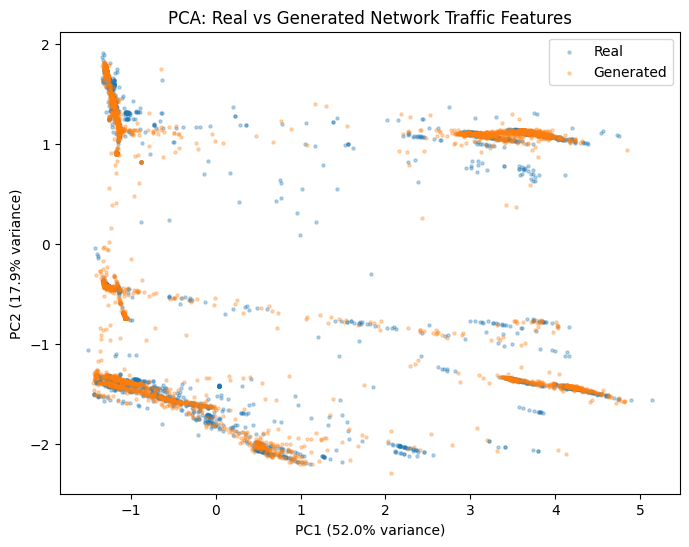

In [11]:
from sklearn.decomposition import PCA
np.random.seed(42)

n_compare_samples = 5000

# Sample real data
real_idx = np.random.choice(len(X_scaled), n_compare_samples, replace=False)
real_sample = X_scaled[real_idx]

# Generate the same number of fake samples
generator.eval()
with torch.no_grad():
    noise = torch.randn(n_compare_samples, latent_dim, device=device)
    fake_sample = generator(noise).cpu().numpy()

# Fit PCA on the combined real+fake data so both are projected into the same space
combined = np.vstack([real_sample, fake_sample])
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined)

real_pca = combined_pca[:n_compare_samples]
fake_pca = combined_pca[n_compare_samples:]

plt.figure(figsize=(8, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.3, label="Real", s=5)
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.3, label="Generated", s=5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.title("PCA: Real vs Generated Network Traffic Features")
plt.show()

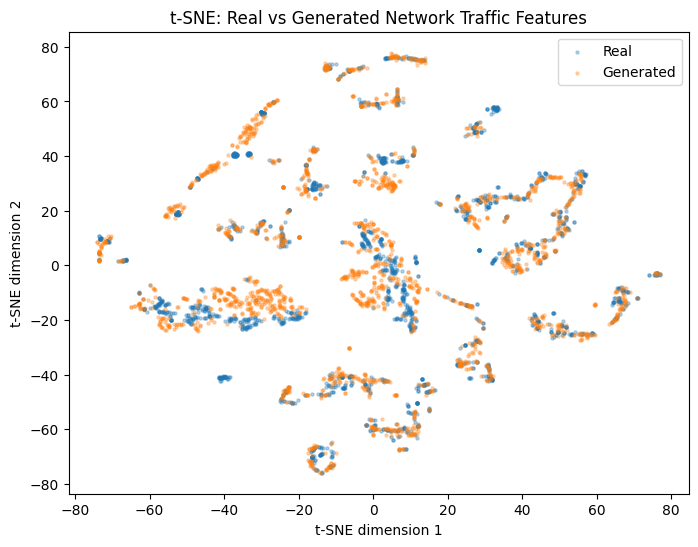

In [12]:
from sklearn.manifold import TSNE

# t-SNE is expensive - use a smaller subsample for reasonable runtime
n_tsne_samples = 2000

real_tsne_idx = np.random.choice(n_compare_samples, n_tsne_samples, replace=False)
combined_tsne_input = np.vstack([
    real_sample[real_tsne_idx],
    fake_sample[real_tsne_idx]
])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
combined_tsne = tsne.fit_transform(combined_tsne_input)

real_tsne = combined_tsne[:n_tsne_samples]
fake_tsne = combined_tsne[n_tsne_samples:]

plt.figure(figsize=(8, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.3, label="Real", s=5)
plt.scatter(fake_tsne[:, 0], fake_tsne[:, 1], alpha=0.3, label="Generated", s=5)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend()
plt.title("t-SNE: Real vs Generated Network Traffic Features")
plt.show()

## Quantifying Distributional Coverage: Cluster-Level Comparison

The PCA and t-SNE plots suggest partial mode collapse: generated samples
concentrate in the dense core of the real distribution but under-represent
outlying regions. This is quantified by clustering the real data and measuring
what fraction of each cluster's "share" is matched by generated samples.

In [13]:
from sklearn.cluster import KMeans

def evaluate_cluster_alignment(real_data, fake_data, n_clusters=8, tolerance=0.05, random_state=42):
    """
    Cluster real data with KMeans, assign generated samples to nearest
    centroid, and compare the resulting cluster-share distributions.
    Returns per-cluster real/generated fractions and total variation distance.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    real_labels = kmeans.fit_predict(real_data)
    fake_labels = kmeans.predict(fake_data.astype(np.float64))

    real_counts = np.bincount(real_labels, minlength=n_clusters)
    fake_counts = np.bincount(fake_labels, minlength=n_clusters)
    real_frac = real_counts / real_counts.sum()
    fake_frac = fake_counts / fake_counts.sum()

    covered = int(np.sum(np.abs(fake_frac - real_frac) < tolerance))
    tv_distance = 0.5 * np.sum(np.abs(real_frac - fake_frac))

    return real_frac, fake_frac, covered, tv_distance


real_frac, fake_frac, covered, tv_distance = evaluate_cluster_alignment(real_sample, fake_sample)

print(f"{'Cluster':>8} {'Real %':>10} {'Generated %':>13} {'Difference':>12}")
for c in range(len(real_frac)):
    diff = fake_frac[c] - real_frac[c]
    print(f"{c:>8} {real_frac[c]:>9.1%} {fake_frac[c]:>12.1%} {diff:>+11.1%}")

print(f"\nClusters with generated share within 5pp of real share: {covered}/{len(real_frac)}")
print(f"Total variation distance between real/generated cluster distributions: {tv_distance:.3f}")

 Cluster     Real %   Generated %   Difference
       0      7.7%         7.0%       -0.7%
       1     17.3%        20.4%       +3.1%
       2     14.1%        15.2%       +1.1%
       3     30.4%        32.2%       +1.8%
       4     13.6%        13.1%       -0.5%
       5      6.8%         7.0%       +0.2%
       6      6.4%         4.3%       -2.0%
       7      3.7%         0.7%       -3.0%

Clusters with generated share within 5pp of real share: 8/8
Total variation distance between real/generated cluster distributions: 0.062


## Evaluating Distributional Alignment

Quantitative cluster-level analysis shows no evidence of mode collapse: all eight clusters, including the smallest (cluster 7, generated at 0.7% against a true share of 3.7%), received proportionate representation in the generated data, with a maximum per-cluster deviation of 3.1 percentage points (cluster 1) and an overall total variation distance of 0.062."

This is a more positive result than the PCA and t-SNE projections alone suggested, and illustrates the value of quantitative cluster-level verification over projection-based visual inspection: PCA and t-SNE necessarily compress 78-dimensional data into two dimensions, which can visually suggest gaps or density differences that do not correspond to genuine proportional misrepresentation once measured directly in the original feature space.

This result is consistent with the training dynamics observed: although the discriminator maintained a persistent loss advantage after an initial adjustment period (epochs 1–6), this advantage did not translate into the generator neglecting minority behavioural clusters, suggesting the generator retained sufficient capacity and gradient signal across the full feature distribution despite the discriminator's edge.

This is an encouraging finding for the practical use case of augmenting an intrusion-detection training set, since even comparatively rare traffic patterns are proportionately represented in the synthetic data rather than being systematically omitted.

## Combined Exploration Across All Days

The dataset spans multiple daily capture files. This section combines all
days for a full picture of features and class balance, as required by the
task. GAN training itself remains scoped to the Wednesday file only, per
the specific task instruction.

In [14]:
import glob

csv_files = glob.glob("/content/*.pcap_ISCX.csv")
print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print(" ", f)

Found 8 files:
  /content/Wednesday-workingHours.pcap_ISCX.csv
  /content/Tuesday-WorkingHours.pcap_ISCX.csv
  /content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  /content/Monday-WorkingHours.pcap_ISCX.csv
  /content/Friday-WorkingHours-Morning.pcap_ISCX.csv
  /content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  /content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  /content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


In [15]:
# Load and combine all daily files. Only load the Label column plus a
# lightweight set of summary stats per file to avoid holding the full
# ~860MB combined dataset in memory at once.
day_summaries = []
for f in csv_files:
    day_df = pd.read_csv(f)
    day_df.columns = day_df.columns.str.strip()
    day_name = f.split("/")[-1].replace(".pcap_ISCX.csv", "")
    label_counts = day_df["Label"].value_counts()
    for label, count in label_counts.items():
        day_summaries.append({"Day": day_name, "Label": label, "Count": count})
    del day_df  # free memory before loading the next file

combined_summary = pd.DataFrame(day_summaries)
print(combined_summary)

                                              Day                       Label  \
0                          Wednesday-workingHours                      BENIGN   
1                          Wednesday-workingHours                    DoS Hulk   
2                          Wednesday-workingHours               DoS GoldenEye   
3                          Wednesday-workingHours               DoS slowloris   
4                          Wednesday-workingHours            DoS Slowhttptest   
5                          Wednesday-workingHours                  Heartbleed   
6                            Tuesday-WorkingHours                      BENIGN   
7                            Tuesday-WorkingHours                 FTP-Patator   
8                            Tuesday-WorkingHours                 SSH-Patator   
9              Friday-WorkingHours-Afternoon-DDos                        DDoS   
10             Friday-WorkingHours-Afternoon-DDos                      BENIGN   
11                          

Total samples per label, across all days:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: Count, dtype: int64

Total samples across all 8 days: 2,830,743


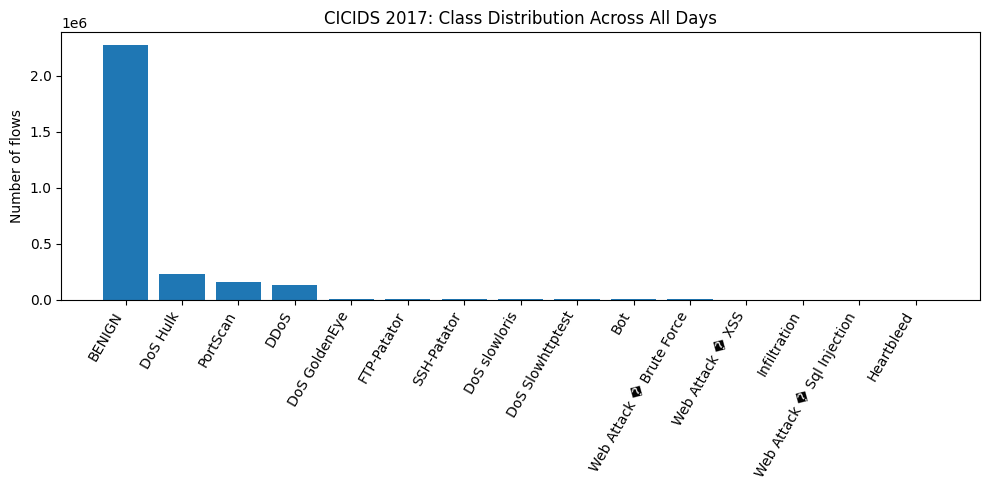

In [16]:
# Overall class balance across the full multi-day dataset
total_by_label = combined_summary.groupby("Label")["Count"].sum().sort_values(ascending=False)
print("Total samples per label, across all days:")
print(total_by_label)

print(f"\nTotal samples across all 8 days: {total_by_label.sum():,}")

plt.figure(figsize=(10, 5))
plt.bar(total_by_label.index, total_by_label.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of flows")
plt.title("CICIDS 2017: Class Distribution Across All Days")
plt.tight_layout()
plt.show()

In [17]:
# Per-day breakdown: which attack types occur on which day
pivot = combined_summary.pivot_table(index="Day", columns="Label", values="Count", fill_value=0)
print(pivot)

Label                                            BENIGN     Bot      DDoS  \
Day                                                                         
Friday-WorkingHours-Afternoon-DDos              97718.0     0.0  128027.0   
Friday-WorkingHours-Afternoon-PortScan         127537.0     0.0       0.0   
Friday-WorkingHours-Morning                    189067.0  1966.0       0.0   
Monday-WorkingHours                            529918.0     0.0       0.0   
Thursday-WorkingHours-Afternoon-Infilteration  288566.0     0.0       0.0   
Thursday-WorkingHours-Morning-WebAttacks       168186.0     0.0       0.0   
Tuesday-WorkingHours                           432074.0     0.0       0.0   
Wednesday-workingHours                         440031.0     0.0       0.0   

Label                                          DoS GoldenEye  DoS Hulk  \
Day                                                                      
Friday-WorkingHours-Afternoon-DDos                       0.0       0.0   
Friday-